Laboratorio 2, Fisica Computacional

Juan Manuel Patiño Daza

In [6]:
#librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# 1
 Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galon.csv. Contruya el fit al C.L. Usar seaborn. Give some conclusions

In [63]:
#cargamos el dataset ademas que visualizamos los primeros 5 elementos
df = pd.read_csv("/content/millas_por_galon.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


como se aprecia de la informacion del dataset, cada columna tiene 398 filas, pero la columna de caballos de fuerza tiene 6 nulos

In [57]:
#copiamos las columnas que nos importan para no adulterar el datset original
dfg = df[["mpg", "horsepower"]]
dfg.head()

,mpg,horsepower
0,18.0,130.0
1,15.0,165.0
2,18.0,150.0
3,16.0,150.0
4,17.0,140.0


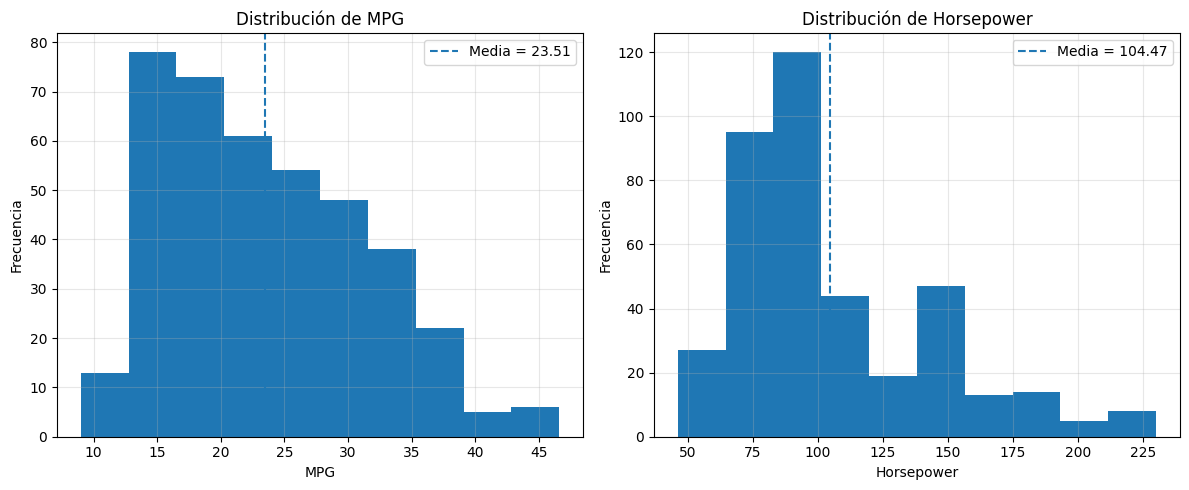

In [65]:
#visualizamos como se distribuyen los datos en histogramas

media_mpg = dfg["mpg"].mean()
media_hp = dfg["horsepower"].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# histograma MPG
ax[0].hist(dfg["mpg"].dropna(), bins=10)
ax[0].axvline(media_mpg, linestyle="--", label=f"Media = {media_mpg:.2f}")
ax[0].set_xlabel("MPG")
ax[0].set_ylabel("Frecuencia")
ax[0].set_title("Distribución de MPG")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# histograma Horsepower
ax[1].hist(dfg["horsepower"].dropna(), bins=10)
ax[1].axvline(media_hp, linestyle="--", label=f"Media = {media_hp:.2f}")
ax[1].set_xlabel("Horsepower")
ax[1].set_ylabel("Frecuencia")
ax[1].set_title("Distribución de Horsepower")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

In [66]:
'''
aunque una solucion para tener la misma cantidad de datos de cada variable en este
caso queremos mantener la mayor cantidad de informacion del dataset original entonces
vamos a remplazar los nulos por la media, una posible solucion es eliminar la fila
donde se presentan los nulos
'''

dfg["horsepower"] = dfg["horsepower"].fillna(media_hp)
print(dfg.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mpg         398 non-null    float64
 1   horsepower  398 non-null    float64
dtypes: float64(2)
memory usage: 6.3 KB
None


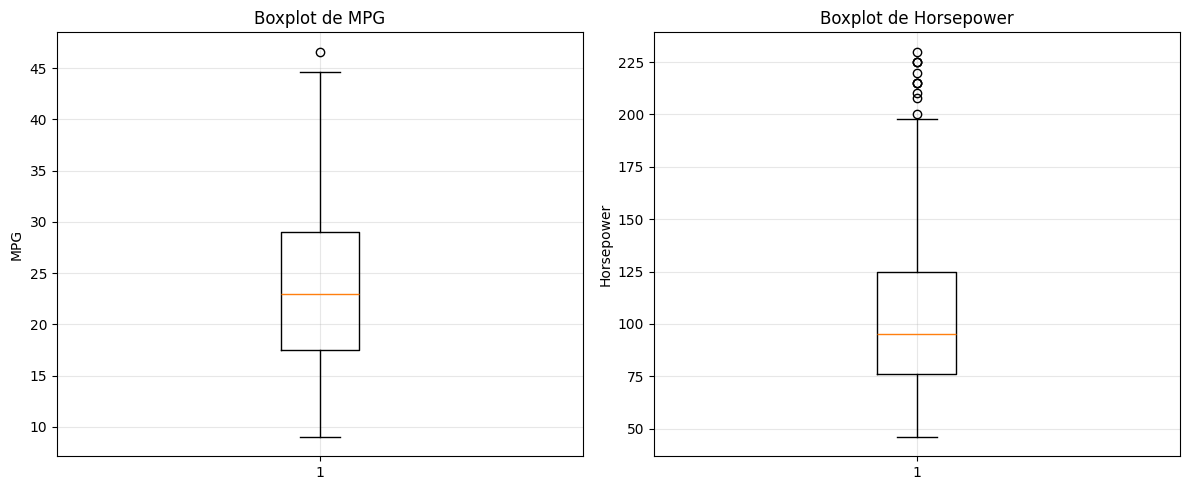

In [71]:
# Crear figura con dos gráficos
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot de MPG
ax[0].boxplot(dfg["mpg"])
ax[0].set_title("Boxplot de MPG")
ax[0].set_ylabel("MPG")
ax[0].grid(True, alpha=0.3)

# Boxplot de Horsepower
ax[1].boxplot(dfg["horsepower"])
ax[1].set_title("Boxplot de Horsepower")
ax[1].set_ylabel("Horsepower")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [132]:
correlacion = np.corrcoef(dfg["mpg"], dfg["horsepower"])[0, 1]
print(f"correlacion entre MPG y Horsepower: {correlacion}")

correlacion entre MPG y Horsepower: -0.7714371350025522


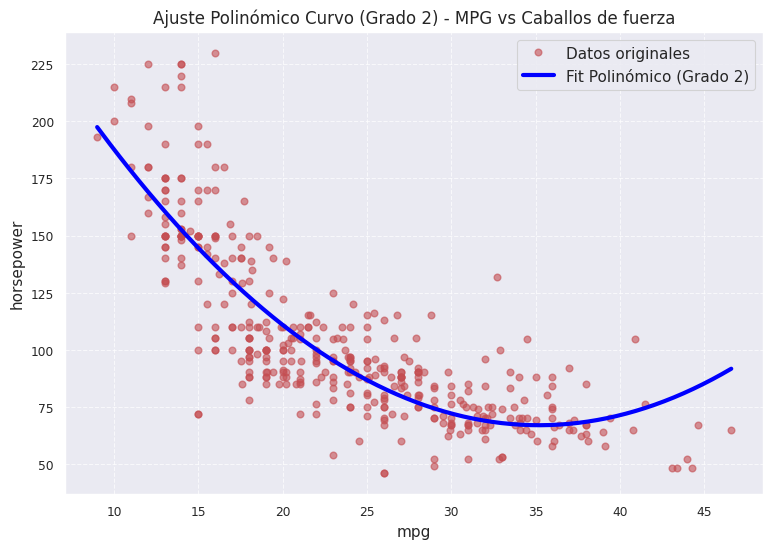

In [92]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

X = dfg[['mpg']].values
y = dfg['horsepower'].values

modelo_poli = make_pipeline(PolynomialFeatures(2), LinearRegression()) #creamos un modelo polinomico
modelo_poli.fit(X, y) #Entrenamos un modelo

X_sec = np.linspace(X.min(), X.max(), 200).reshape(-1, 1) #creamos un espacio lineal
y_pred_curva = modelo_poli.predict(X_sec)

plt.figure(figsize=(9, 6))
plt.title(f"Ajuste Polinómico Curvo (Grado 2) - MPG vs Caballos de fuerza", fontsize=12)
plt.plot(dfg.mpg, dfg.horsepower, "ro", alpha=0.6, label="Datos originales")
plt.plot(X_sec, y_pred_curva, color="blue", linewidth=3, label=f"Fit Polinómico (Grado {2})") #curva del ajuste
plt.xlabel("mpg", fontsize=11)
plt.ylabel("horsepower", fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

Conclusiones:



*   El diagrama boxplot nos muestra que hay valores atipicos en los datos de MPG lo que significa que hay carros con una eficiencia superior a los demas carros del dataset
*  El diagrama boxplot de caballos de fuerza mostro que hay mas valores atipicos aunque estos no significa que los datos esten incorrectos, mas bien hay super carros que tienen una potencia significativamente mayor que los demas carros en la lista
* una correlacion -0.77 significa que son inversamente proporcionales, es decir que mientras mas potencia tiene un automovil recorre una manor distancia por galon
* el ajuste escogido es una funcion cuadratica puesto que una funcion lineal no ajustaba tan bien como si lo logra hacer la funcion cuadratica




#2
 Descargar el dataframe : https://github.com/anferivera/SDdiracDM/blob/master/general-scan.csv desde GitHUb y reconstruir la figura 6 del trabajo. Para ello usar seaborn y matplolib.


In [12]:
df2 = pd.read_csv("/content/general-scan.csv")
df2.head()

,Unnamed: 0,MDF,MS12,MS22,LamS1H,LamS2H,LamSPH,LamS,LamSP,vS,...,U,mueg,taumug,sv,ZH11,ZH12,ZH21,ZH22,BRh1gg,BRh2gg
0,0,396.848661,2.137304e+06,2.137304e+06,0.020984,0.020984,0.020052,0.0,0.217236,702.109163,...,0.001075,0.0,1.773785e-19,1.860000e-26,0.999293,-0.037599,0.037599,0.999293,0.002837,0.000000
1,1,5988.499243,1.889315e+07,1.889315e+07,0.023341,0.023341,0.000181,0.0,0.019173,329.668504,...,-0.002513,0.0,1.791040e-18,2.580000e-31,0.001084,-0.999999,-0.999999,-0.001084,0.000342,0.002816
2,2,452.875632,2.469280e+06,2.469280e+06,0.000490,0.000490,0.017861,0.0,0.337367,3843.138599,...,0.000638,0.0,4.833919e-18,1.220000e-26,0.999994,-0.003384,0.003384,0.999994,0.002822,0.000000
3,3,589.443344,9.826674e+07,9.826674e+07,0.042790,0.042790,0.031174,0.0,0.270921,314.258778,...,0.000181,0.0,9.406560e-16,2.740000e-30,0.979480,-0.201541,0.201541,0.979480,0.002838,0.000194
4,4,1092.250036,2.054042e+06,2.054042e+06,0.002196,0.002196,0.002346,0.0,0.046671,13048.623894,...,0.000066,0.0,1.002187e-13,1.970000e-26,1.000000,-0.000945,0.000945,1.000000,0.002827,0.000000


In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17396 entries, 0 to 17395
Data columns (total 60 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  17396 non-null  int64  
 1   MDF         17396 non-null  float64
 2   MS12        17396 non-null  float64
 3   MS22        17396 non-null  float64
 4   LamS1H      17396 non-null  float64
 5   LamS2H      17396 non-null  float64
 6   LamSPH      17396 non-null  float64
 7   LamS        17396 non-null  float64
 8   LamSP       17396 non-null  float64
 9   vS          17396 non-null  float64
 10  YRD         17396 non-null  float64
 11  YRC         17396 non-null  float64
 12  YRA11       17396 non-null  float64
 13  YRA12       17396 non-null  float64
 14  YRA13       17396 non-null  float64
 15  YRA21       17396 non-null  float64
 16  YRA22       17396 non-null  float64
 17  YRA23       17396 non-null  float64
 18  YRB11       17396 non-null  float64
 19  YRB12       17396 non-nul

In [129]:
dfz = df2[["vS", "YRC", "MDF", "mChi1", "Omega"]]
Mn = dfz["YRC"] * dfz["vS"] * (1/np.sqrt(2))
omegaDM = 0.12

dfz['Mn'] = Mn

/tmp/ipykernel_3168/1885997358.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfz['Mn'] = Mn


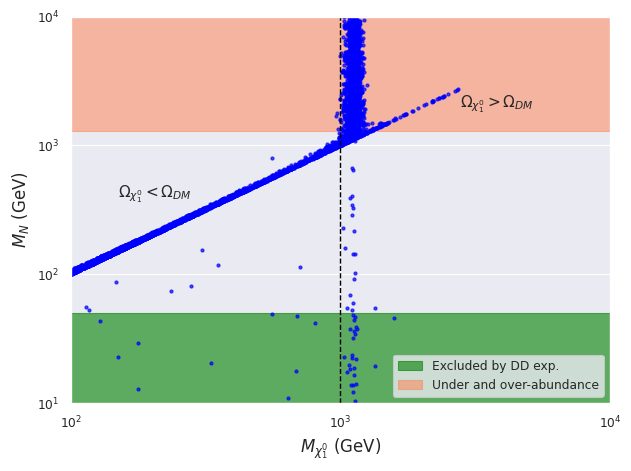

In [128]:
x = dfz["mChi1"]
y = dfz["Mn"]
omega = dfz["Omega"]

plt.axhspan(
    ymin=10,
    ymax=50,
    color="green",
    alpha=0.6,
    label="Excluded by DD exp."
)

plt.axhspan(
    ymin=1300,
    ymax=10000,
    xmin=0,
    xmax=1,
    color="coral",
    alpha=0.5,
    label="Under and over-abundance",
)

# 3. Graficar los puntos del modelo (scatter plot en azul)
plt.scatter(x, y, color="blue", s=5, alpha=0.7)

# Línea vertical discontinua de referencia (ejemplo en mChi1 = 1000 GeV)
plt.axvline(x=1000, color="black", linestyle="--", linewidth=1)

plt.yscale("log")
plt.xscale("log")

plt.xlim(100, 10000)
plt.ylim(10, 10000)

plt.xlabel(r"$M_{\chi_1^0}$ (GeV)", fontsize=12)
plt.ylabel(r"$M_N$ (GeV)", fontsize=12)

# Añadir textos explicativos dentro del gráfico
plt.text(150, 400, r"$\Omega_{\chi_1^0} < \Omega_{DM}$", fontsize=11)
plt.text(
    3800,
    2000,
    r"$\Omega_{\chi_1^0} > \Omega_{DM}$",
    fontsize=11,
    ha="center",
)

# Leyenda y presentación
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()